In [79]:

# Leer datos del archivo
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/StreamingHistory_Extended.csv"
# Leer datos del archivo
spotify : pd.DataFrame = pd.read_csv(archivo)
spotify

KeyboardInterrupt: 

In [50]:
#1
spotify.dtypes

ts                                      str
username                              int64
platform                                str
ms_played                             int64
conn_country                            str
user_agent_decrypted                    str
master_metadata_track_name              str
master_metadata_album_artist_name       str
master_metadata_album_album_name        str
spotify_track_uri                       str
episode_name                            str
episode_show_name                       str
spotify_episode_uri                     str
reason_start                            str
reason_end                              str
shuffle                                bool
skipped                              object
offline                                bool
offline_timestamp                     int64
is_podcast                             bool
dtype: object

In [51]:
#2
print(spotify["ts"].max())
print(spotify["ts"].min())

2024-05-23T23:56:20Z
2014-06-27T18:01:15Z


In [52]:
#3
spotify["spotify_track_uri"].unique().value_counts().size

11556

In [53]:
#4
spotify["ms_played"].sum()

np.int64(12583875841)

In [62]:
#5
artistamasescuchado =spotify.groupby(spotify["master_metadata_album_artist_name"])["ms_played"].sum().idxmax()
artistamasescuchado

'Charly García'

In [ ]:
#6
spotify.groupby(spotify["master_metadata_track_name"])["ms_played"].sum().idxmax()

'Rain'

In [86]:
#7
lista_artistamasecuchado =spotify[artistamasescuchado == spotify["master_metadata_album_artist_name"]]
lista_artistamasecuchado.groupby(lista_artistamasecuchado["master_metadata_track_name"])["ms_played"].sum().idxmax()

'Hablando a Tu Corazón'

In [87]:
# 1. Group by track name
# 2. Sum the columns (specifically ms_played)
# 3. Sort from highest to lowest play time
top_tracks = (
    spotify.groupby("master_metadata_track_name")["ms_played"]
    .sum()
    .sort_values(ascending=False)
)

print(top_tracks)


master_metadata_track_name
Rain                                           76588367
Redbone                                        64432883
Free Bird                                      48294521
Spain                                          46220252
Something About Us                             45732605
                                                 ...   
Por la boca vive el pez                               0
Blue Monday - 2016 Remaster                           0
Tremor - Sensation 2014 Anthem                        0
Travelling Without Moving - Remastered 2013           0
Block Rockin' Beats                                   0
Name: ms_played, Length: 9708, dtype: int64


8


TypeError: tuple indices must be integers or slices, not str

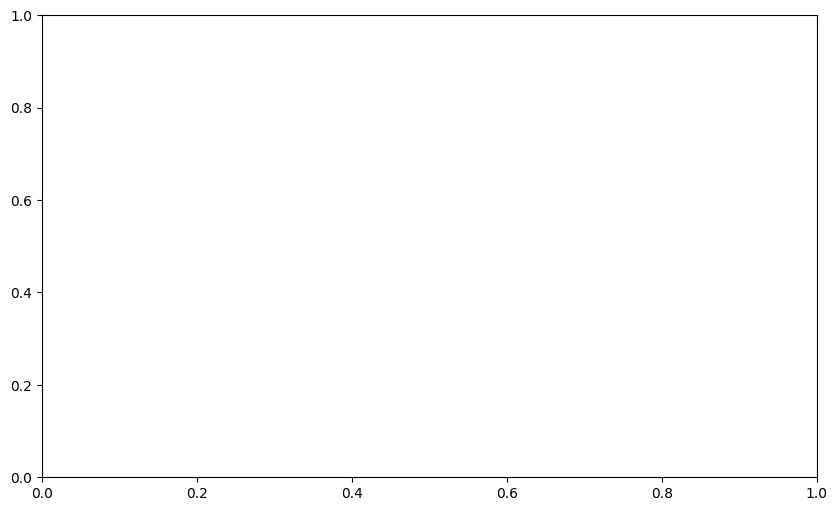

In [81]:
#8
fig, ax = plt.subplots(figsize=(10, 6))
bar_labels =list(sorted(spotify.groupby(spotify["master_metadata_track_name"]), key=lambda x: x["ms_played"].sum(), reverse=True))
counts = 10
ax.bar(bar_labels, counts)
ax.set_ylabel('Goles Totales')
ax.set_title('Goles Totales de Equipos Campeones del mundo')

plt.show()